RQ1: Can introducing semantically valid, artificially crafted, and maliciously altered network flow perturbations, creating the effects of a network poisoning attack, into an IDS training dataset, such as the Unified Multimodal NIDS CIC-IDS2019 dataset, reduce the robustness of the training of the model?

H10: Using bootstrap resampling to estimate precision, recall, and FPR with 95% confidence intervals, introducing perturbations to the model’s training dataset has no statistically significant effect on the model's overall performance.

H1a: Using bootstrap resampling to estimate precision, recall, and FPR with 95% confidence intervals, introducing perturbations to the model’s training dataset has a statistically significant effect on the model's overall performance.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import  accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
from xgboost import XGBClassifier

In [2]:
df_sample = pd.read_csv("clean_sample_150000.csv")

In [3]:
le = LabelEncoder()
df_sample["label"] = le.fit_transform(df_sample["label"])
X = df_sample.drop(columns=["label"], errors="ignore").select_dtypes(include=[np.number])
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(0, inplace=True)
y = df_sample["label"]
label_mapping = dict(zip(le.classes_, range(len(le.classes_))))

In [4]:
def base_xgb(): return XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.03, eval_metric="mlogloss", random_state=42, tree_method="hist")

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")
y_test = y_test.reset_index(drop=True).to_numpy()
model = base_xgb()
model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [6]:
proba_train = model.predict_proba(X_train)
y_train_arr = y_train.reset_index(drop=True).to_numpy()
attack_mask = y_train_arr != 0
atk_idx = np.where(attack_mask)[0]
atk_X = X_train.reset_index(drop=True).iloc[atk_idx]
atk_y = y_train_arr[atk_idx]
atk_proba = proba_train[atk_idx]
true_class_conf = atk_proba[np.arange(len(atk_y)), atk_y]
order = np.argsort(true_class_conf)
boundary_X = atk_X.iloc[order].reset_index(drop=True)
boundary_y = atk_y[order]
boundary_conf = true_class_conf[order]
boundary_df = boundary_X.copy()
boundary_df["true_label"] = boundary_y
boundary_df["confidence"] = boundary_conf
boundary_df.to_csv("boundary_attacks.csv", index=False)
print(f"Saved {len(boundary_df)} boundary-adjacent attack samples")
print(f"Confidence range: {boundary_conf.min():.4f} – {boundary_conf.max():.4f}")
print(f"Bottom 10% confidence threshold: {np.percentile(boundary_conf, 10):.4f}")

Saved 80000 boundary-adjacent attack samples
Confidence range: 0.0487 – 0.9998
Bottom 10% confidence threshold: 0.4304


In [7]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Weighted F1:", f1_score(y_test, y_pred, average='weighted'))
print("Macro F1:", f1_score(y_test, y_pred, average='macro'))
print("ROC-AUC:", roc_auc_score(y_test, y_prob, multi_class="ovr", average="weighted"))

Accuracy: 0.9070666666666667
Weighted F1: 0.9069017276411161
Macro F1: 0.9069017276411162
ROC-AUC: 0.9828945200000001


In [8]:
print(classification_report(y_test, y_pred, target_names=le.classes_))

                precision    recall  f1-score   support

        BENIGN       1.00      1.00      1.00     10000
    DoS_ATTACK       0.89      0.82      0.85     10000
NON_DoS_ATTACK       0.83      0.90      0.87     10000

      accuracy                           0.91     30000
     macro avg       0.91      0.91      0.91     30000
  weighted avg       0.91      0.91      0.91     30000



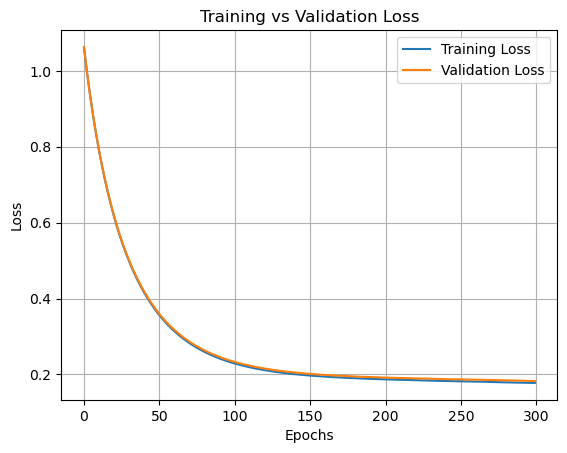

In [9]:
results = model.evals_result()
train_loss = results['validation_0']['mlogloss']
val_loss   = results['validation_1']['mlogloss']
plt.figure()
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid()
plt.show()

In [10]:
noise_df = pd.read_csv("noise_epsilon_0.2.csv")
noise_X = noise_df.drop(columns=["true_label","y_pred"], errors="ignore").select_dtypes(include=[np.number])
noise_X.replace([np.inf, -np.inf], np.nan, inplace=True)
noise_X.fillna(0, inplace=True)
noise_y = noise_df["true_label"].reset_index(drop=True).values
noise_y_pred = noise_df["y_pred"].reset_index(drop=True).values
noise_X = noise_X.astype("float32")
noise_pred = model.predict(noise_X)
noise_prob = model.predict_proba(noise_X)
print("Accuracy:", accuracy_score(noise_y, noise_pred))
print("Weighted F1:", f1_score(noise_y, noise_pred, average='weighted'))
print("Macro F1:", f1_score(noise_y, noise_pred, average='macro'))

Accuracy: 0.538738647318484
Weighted F1: 0.6011520839201915
Macro F1: 0.24375636813687163


In [11]:
from sklearn.metrics import classification_report
present_labels = np.unique(np.concatenate([noise_y, noise_pred]))
print(classification_report(noise_y, noise_pred, target_names=le.classes_[present_labels]))

                precision    recall  f1-score   support

        BENIGN       0.00      0.00      0.00      1693
    DoS_ATTACK       0.02      0.11      0.03      1096
NON_DoS_ATTACK       0.80      0.62      0.70     16920

      accuracy                           0.54     19709
     macro avg       0.27      0.25      0.24     19709
  weighted avg       0.69      0.54      0.60     19709



In [12]:
adv_df = pd.read_csv("adversarial_epsilon_0.2.csv")
adv_X = adv_df.drop(columns=["true_label","pred_clean", "pred_adv"], errors="ignore").select_dtypes(include=[np.number])
adv_X.replace([np.inf, -np.inf], np.nan, inplace=True)
adv_X.fillna(0, inplace=True)
adv_y = adv_df["true_label"].reset_index(drop=True).values
adv_X = adv_X.astype("float32")
adv_pred = model.predict(adv_X)
adv_prob = model.predict_proba(adv_X)
print("Accuracy:", accuracy_score(adv_y, adv_pred))
print("Weighted F1:", f1_score(adv_y, adv_pred, average='weighted'))
print("Macro F1:", f1_score(adv_y, adv_pred, average='macro'))

Accuracy: 0.4095744680851064
Weighted F1: 0.4082182457533392
Macro F1: 0.4082182457533392


In [13]:
from sklearn.metrics import classification_report
present_labels = np.unique(np.concatenate([adv_y, adv_pred]))
print(classification_report(adv_y, adv_pred, target_names=le.classes_[present_labels], zero_division=0))

                precision    recall  f1-score   support

    DoS_ATTACK       0.40      0.36      0.38        94
NON_DoS_ATTACK       0.42      0.46      0.44        94

      accuracy                           0.41       188
     macro avg       0.41      0.41      0.41       188
  weighted avg       0.41      0.41      0.41       188



In [14]:
hsj_df = pd.read_csv("adversarial_hsj_xgb.csv")
hsj_X = hsj_df.drop(columns=["true_label","pred_clean", "pred_adv"], errors="ignore").select_dtypes(include=[np.number])
hsj_X.replace([np.inf, -np.inf], np.nan, inplace=True)
hsj_X.fillna(0, inplace=True)
hsj_y = hsj_df["true_label"].reset_index(drop=True).values
hsj_X = hsj_X.astype("float32")
hsj_pred = model.predict(hsj_X)
hsj_prob = model.predict_proba(hsj_X)
print("Accuracy:", accuracy_score(hsj_y, hsj_pred))
print("Weighted F1:", f1_score(hsj_y, hsj_pred, average='weighted'))
print("Macro F1:", f1_score(hsj_y, hsj_pred, average='macro'))

Accuracy: 0.0
Weighted F1: 0.0
Macro F1: 0.0


In [15]:
boundary_df = pd.read_csv("boundary_attacks.csv")
boundary_X = boundary_df.drop(columns=["true_label", "confidence"], errors="ignore").select_dtypes(include=[np.number])
boundary_X.replace([np.inf, -np.inf], np.nan, inplace=True)
boundary_X.fillna(0, inplace=True)
boundary_y = boundary_df["true_label"].reset_index(drop=True).values
boundary_X = boundary_X.astype("float32")
print(f"Boundary samples: {len(boundary_df)}, class distribution: {dict(zip(*np.unique(boundary_y, return_counts=True)))}")

Boundary samples: 80000, class distribution: {np.int64(1): np.int64(40000), np.int64(2): np.int64(40000)}


In [16]:
from sklearn.metrics import classification_report
present_labels = np.unique(np.concatenate([adv_y, adv_pred]))
print(classification_report(adv_y, adv_pred, target_names=le.classes_[present_labels], zero_division=0))

                precision    recall  f1-score   support

    DoS_ATTACK       0.40      0.36      0.38        94
NON_DoS_ATTACK       0.42      0.46      0.44        94

      accuracy                           0.41       188
     macro avg       0.41      0.41      0.41       188
  weighted avg       0.41      0.41      0.41       188



In [17]:
def poison_training_set(X_train, y_train, ae_X, ae_y, poison_rate, random_state=42):
    ae_X = ae_X[X_train.columns]
    rng = np.random.default_rng(random_state)
    n_total = len(X_train)
    n_poison = int(n_total * poison_rate)
    X_clean = X_train.reset_index(drop=True).copy()
    y_clean = y_train.reset_index(drop=True).to_numpy().copy()
    if n_poison == 0:
        shuffle_idx = rng.permutation(n_total)
        return X_clean.iloc[shuffle_idx].reset_index(drop=True), y_clean[shuffle_idx]
    attack_mask = ae_y != 0
    ae_X_attacks = ae_X[attack_mask].reset_index(drop=True)
    ae_y_attacks = ae_y[attack_mask]
    chosen = rng.choice(len(ae_X_attacks), size=n_poison, replace=(n_poison > len(ae_X_attacks)))
    X_poison = ae_X_attacks.iloc[chosen].reset_index(drop=True).copy()
    y_poison = np.zeros(n_poison, dtype=int)  # mislabel all as BENIGN
    keep_mask = np.ones(n_total, dtype=bool)
    train_classes = np.unique(y_clean)
    class_train_counts = np.array([np.sum(y_clean == c) for c in train_classes])
    class_train_fracs = class_train_counts / n_total
    drop_per_class = np.floor(class_train_fracs * n_poison).astype(int)
    drop_remainder = n_poison - drop_per_class.sum()
    drop_order = np.argsort(-class_train_fracs)
    for i in range(drop_remainder):
        drop_per_class[drop_order[i % len(train_classes)]] += 1
    for i, cls in enumerate(train_classes):
        cls_idx = np.where(y_clean == cls)[0]
        n_drop = min(drop_per_class[i], len(cls_idx))
        to_drop = rng.choice(cls_idx, size=n_drop, replace=False)
        keep_mask[to_drop] = False
    keep_idx = np.where(keep_mask)[0]
    n_keep = n_total - n_poison
    if len(keep_idx) > n_keep:
        excess = len(keep_idx) - n_keep
        trim_mask = np.ones(len(keep_idx), dtype=bool)
        kept_classes, kept_counts = np.unique(y_clean[keep_idx], return_counts=True)
        kept_fracs = kept_counts / kept_counts.sum()
        trim_per_class = np.floor(kept_fracs * excess).astype(int)
        trim_rem = excess - trim_per_class.sum()
        trim_order = np.argsort(-kept_fracs)
        for j in range(trim_rem):
            trim_per_class[trim_order[j % len(kept_classes)]] += 1
        for j, cls in enumerate(kept_classes):
            cls_positions = np.where(y_clean[keep_idx] == cls)[0]
            to_trim = rng.choice(cls_positions, size=trim_per_class[j], replace=False)
            trim_mask[to_trim] = False
        keep_idx = keep_idx[trim_mask]
    elif len(keep_idx) < n_keep:
        extra_pool = np.where(~keep_mask)[0]
        extra = rng.choice(extra_pool, size=n_keep - len(keep_idx), replace=False)
        keep_idx = np.concatenate([keep_idx, extra])
    X_kept = X_clean.iloc[keep_idx].reset_index(drop=True)
    y_kept = y_clean[keep_idx]
    X_poisoned = pd.concat([X_kept, X_poison], ignore_index=True)
    y_poisoned = np.concatenate([y_kept, y_poison])
    shuffle_idx = rng.permutation(len(X_poisoned))
    return X_poisoned.iloc[shuffle_idx].reset_index(drop=True), y_poisoned[shuffle_idx]

In [18]:
def fpr_benign(y_true, y_pred):
    labels = np.unique(y_true)
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    benign_idx = np.where(labels == 0)[0][0]
    fp = cm[:, benign_idx].sum() - cm[benign_idx, benign_idx]
    n_non_benign = cm.sum() - cm[benign_idx].sum()
    tn = n_non_benign - fp
    return fp / (fp + tn + 1e-10)

In [19]:
GROUPS = {
    "Control (0%)":      0.00,
    "Experiment 1 (5%)": 0.05,
    "Experiment 2 (10%)": 0.10,
    "Experiment 3 (15%)": 0.15,
    "Experiment 4 (20%)": 0.20,
    "Experiment 5 (25%)": 0.25,
    "Experiment 6 (30%)": 0.30,
    "Experiment 7 (35%)": 0.35,
    "Experiment 8 (40%)": 0.40,
    "Experiment 9 (45%)": 0.45,
    "Experiment 10 (50%)": 0.50,
 #   "Experiment 11 (55%)": 0.55,
 #   "Experiment 12 (60%)": 0.60,
 #   "Experiment 13 (65%)": 0.65,
 #   "Experiment 14 (70%)": 0.70,
 #   "Experiment 15 (75%)": 0.75,
 #   "Experiment 16 (80%)": 0.80,
 #   "Experiment 17 (85%)": 0.85,
 #   "Experiment 18 (90%)": 0.90,
 #   "Experiment 19 (95%)": 0.95,
 #   "Experiment 20 (100%)": 1.00,
}

N_BOOTSTRAPS = 500

In [20]:
all_results = {"Noise": [], "Adversarial": [], "HSJ": [], "Boundary": []}
group_preds = {"Noise": {}, "Adversarial": {}, "HSJ": {}, "Boundary": {}}
for source_name, (ae_X, ae_y) in [("Noise", (noise_X, noise_y)), ("Adversarial", (adv_X, adv_y)), ("HSJ", (hsj_X, hsj_y)), ("Boundary", (boundary_X, boundary_y))]:
    for group_name, poison_rate in GROUPS.items():
        X_tr, y_tr = poison_training_set(X_train, y_train, ae_X, ae_y, poison_rate)
        exp_model = base_xgb()
        exp_model.fit(X_tr, y_tr)
        y_pred = np.array(exp_model.predict(X_test))
        bootstrap_indices = [resample(np.arange(len(y_test)), replace=True) for _ in range(N_BOOTSTRAPS)]
        group_preds[source_name][group_name] = y_pred
        acc  = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
        rec  = recall_score(y_test, y_pred, average="macro", zero_division=0)
        mac  = f1_score(y_test, y_pred, average="macro", zero_division=0)
        wt   = f1_score(y_test, y_pred, average="weighted", zero_division=0)
        fpr  = fpr_benign(y_test, y_pred)
        acc_b, prec_b, rec_b, mac_b, wt_b, fpr_b = [], [], [], [], [], []
        for idx in bootstrap_indices:
            acc_b.append(accuracy_score(y_test[idx], y_pred[idx]))
            prec_b.append(precision_score(y_test[idx], y_pred[idx], average="macro", zero_division=0))
            rec_b.append(recall_score(y_test[idx], y_pred[idx], average="macro", zero_division=0))
            mac_b.append(f1_score(y_test[idx], y_pred[idx], average="macro", zero_division=0))
            wt_b.append(f1_score(y_test[idx], y_pred[idx], average="weighted", zero_division=0))
            fpr_b.append(fpr_benign(y_test[idx], y_pred[idx]))
        def ci(vals): return np.percentile(vals, 2.5), np.percentile(vals, 97.5)
        all_results[source_name].append({
            "Group": group_name,
            "Poison Rate": poison_rate,
            "Accuracy": round(acc, 4),        "Acc CI": ci(acc_b),
            "Macro Precision": round(prec, 4), "Prec CI": ci(prec_b),
            "Macro Recall": round(rec, 4),     "Rec CI": ci(rec_b),
            "Macro F1": round(mac, 4),         "MacF1 CI": ci(mac_b),
            "Weighted F1": round(wt, 4),       "WtF1 CI": ci(wt_b),
            "Benign FPR": round(fpr, 4),       "FPR CI": ci(fpr_b),
        })

In [21]:
for source_name, results in all_results.items():
    print(f"\n\n══ {source_name.upper()} — SUMMARY WITH 95% BOOTSTRAP CIs ══")
    summary = pd.DataFrame([{
        "Group": r["Group"],
        "Poison Rate": f"{int(r['Poison Rate']*100)}%",
        "Accuracy": f"{r['Accuracy']} [{r['Acc CI'][0]:.4f}, {r['Acc CI'][1]:.4f}]",
        "Macro Precision": f"{r['Macro Precision']} [{r['Prec CI'][0]:.4f}, {r['Prec CI'][1]:.4f}]",
        "Macro Recall": f"{r['Macro Recall']} [{r['Rec CI'][0]:.4f}, {r['Rec CI'][1]:.4f}]",
        "Macro F1": f"{r['Macro F1']} [{r['MacF1 CI'][0]:.4f}, {r['MacF1 CI'][1]:.4f}]",
        "Weighted F1": f"{r['Weighted F1']} [{r['WtF1 CI'][0]:.4f}, {r['WtF1 CI'][1]:.4f}]",
    } for r in results])
    display(summary)

    print(f"\n══ {source_name.upper()} — BOOTSTRAP p-VALUES vs CONTROL ══")
    ctrl_pred = group_preds[source_name]["Control (0%)"]
    hyp_results = []
    for group_name, poison_rate in GROUPS.items():
        if poison_rate == 0.0:
            continue
        exp_pred = group_preds[source_name][group_name]
        diffs = []
        for _ in range(N_BOOTSTRAPS):
            idx = resample(np.arange(len(y_test)), replace=True)
            diffs.append(f1_score(y_test[idx], ctrl_pred[idx], average="macro", zero_division=0) -
                         f1_score(y_test[idx], exp_pred[idx], average="macro", zero_division=0))
        diffs = np.array(diffs)
        p = min(np.mean(diffs <= 0), np.mean(diffs >= 0)) * 2
        hyp_results.append({
            "Comparison": f"Control vs {group_name}",
            "Mean F1 Drop": round(np.mean(diffs), 4),
            "95% CI": f"[{np.percentile(diffs,2.5):.4f}, {np.percentile(diffs,97.5):.4f}]",
            "p-value": round(p, 6),
            "Significant": "Yes" if p < 0.05 else "No",
        })
    display(pd.DataFrame(hyp_results))



══ NOISE — SUMMARY WITH 95% BOOTSTRAP CIs ══


,Group,Poison Rate,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Control (0%),0%,"0.9069 [0.9037, 0.9101]","0.9085 [0.9057, 0.9115]","0.9069 [0.9039, 0.9099]","0.9067 [0.9037, 0.9097]","0.9067 [0.9036, 0.9099]"
1,Experiment 1 (5%),5%,"0.9069 [0.9037, 0.9101]","0.9087 [0.9055, 0.9116]","0.9069 [0.9038, 0.9099]","0.9068 [0.9036, 0.9098]","0.9068 [0.9035, 0.9099]"
2,Experiment 2 (10%),10%,"0.9069 [0.9033, 0.9103]","0.9086 [0.9054, 0.9118]","0.9069 [0.9035, 0.9100]","0.9067 [0.9034, 0.9099]","0.9067 [0.9031, 0.9101]"
3,Experiment 3 (15%),15%,"0.9067 [0.9035, 0.9100]","0.9082 [0.9050, 0.9114]","0.9067 [0.9036, 0.9100]","0.9066 [0.9035, 0.9098]","0.9066 [0.9033, 0.9099]"
4,Experiment 4 (20%),20%,"0.9063 [0.9033, 0.9093]","0.9079 [0.9049, 0.9108]","0.9063 [0.9034, 0.9091]","0.9062 [0.9032, 0.9090]","0.9062 [0.9031, 0.9092]"
5,Experiment 5 (25%),25%,"0.9059 [0.9027, 0.9093]","0.9076 [0.9046, 0.9110]","0.9059 [0.9027, 0.9094]","0.9057 [0.9026, 0.9092]","0.9057 [0.9025, 0.9091]"
6,Experiment 6 (30%),30%,"0.9066 [0.9033, 0.9100]","0.908 [0.9048, 0.9112]","0.9066 [0.9034, 0.9099]","0.9065 [0.9030, 0.9097]","0.9065 [0.9031, 0.9098]"
7,Experiment 7 (35%),35%,"0.9065 [0.9033, 0.9096]","0.9079 [0.9046, 0.9111]","0.9065 [0.9032, 0.9096]","0.9063 [0.9031, 0.9094]","0.9063 [0.9032, 0.9095]"
8,Experiment 8 (40%),40%,"0.9058 [0.9023, 0.9089]","0.9074 [0.9040, 0.9104]","0.9058 [0.9025, 0.9089]","0.9057 [0.9023, 0.9087]","0.9057 [0.9022, 0.9087]"
9,Experiment 9 (45%),45%,"0.9059 [0.9026, 0.9092]","0.9076 [0.9044, 0.9109]","0.9059 [0.9028, 0.9092]","0.9057 [0.9024, 0.9091]","0.9057 [0.9024, 0.9090]"



══ NOISE — BOOTSTRAP p-VALUES vs CONTROL ══


,Comparison,Mean F1 Drop,95% CI,p-value,Significant
0,Control vs Experiment 1 (5%),-0.0000,"[-0.0008, 0.0009]",0.956,No
1,Control vs Experiment 2 (10%),-0.0000,"[-0.0008, 0.0009]",0.992,No
2,Control vs Experiment 3 (15%),0.0002,"[-0.0007, 0.0011]",0.644,No
3,Control vs Experiment 4 (20%),0.0006,"[-0.0004, 0.0015]",0.252,No
4,Control vs Experiment 5 (25%),0.0010,"[0.0002, 0.0019]",0.024,Yes
5,Control vs Experiment 6 (30%),0.0002,"[-0.0009, 0.0013]",0.648,No
6,Control vs Experiment 7 (35%),0.0004,"[-0.0006, 0.0012]",0.448,No
7,Control vs Experiment 8 (40%),0.0011,"[-0.0000, 0.0022]",0.060,No
8,Control vs Experiment 9 (45%),0.0010,"[-0.0000, 0.0020]",0.052,No
9,Control vs Experiment 10 (50%),0.0022,"[0.0010, 0.0034]",0.000,Yes




══ ADVERSARIAL — SUMMARY WITH 95% BOOTSTRAP CIs ══


,Group,Poison Rate,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Control (0%),0%,"0.9069 [0.9038, 0.9104]","0.9085 [0.9056, 0.9120]","0.9069 [0.9040, 0.9104]","0.9067 [0.9037, 0.9102]","0.9067 [0.9036, 0.9102]"
1,Experiment 1 (5%),5%,"0.9064 [0.9029, 0.9096]","0.9078 [0.9045, 0.9109]","0.9064 [0.9032, 0.9094]","0.9062 [0.9030, 0.9093]","0.9062 [0.9028, 0.9094]"
2,Experiment 2 (10%),10%,"0.9056 [0.9020, 0.9083]","0.9072 [0.9038, 0.9099]","0.9056 [0.9021, 0.9083]","0.9054 [0.9018, 0.9081]","0.9054 [0.9019, 0.9082]"
3,Experiment 3 (15%),15%,"0.9059 [0.9024, 0.9091]","0.9074 [0.9041, 0.9105]","0.9059 [0.9025, 0.9091]","0.9057 [0.9023, 0.9090]","0.9057 [0.9023, 0.9089]"
4,Experiment 4 (20%),20%,"0.9058 [0.9025, 0.9093]","0.9073 [0.9041, 0.9107]","0.9058 [0.9026, 0.9091]","0.9056 [0.9023, 0.9090]","0.9056 [0.9024, 0.9092]"
5,Experiment 5 (25%),25%,"0.9049 [0.9016, 0.9081]","0.9066 [0.9035, 0.9097]","0.9049 [0.9017, 0.9081]","0.9048 [0.9014, 0.9080]","0.9048 [0.9014, 0.9079]"
6,Experiment 6 (30%),30%,"0.906 [0.9028, 0.9092]","0.9075 [0.9045, 0.9106]","0.906 [0.9029, 0.9090]","0.9059 [0.9028, 0.9089]","0.9059 [0.9026, 0.9091]"
7,Experiment 7 (35%),35%,"0.9057 [0.9022, 0.9091]","0.9073 [0.9036, 0.9106]","0.9057 [0.9021, 0.9091]","0.9056 [0.9019, 0.9091]","0.9056 [0.9021, 0.9089]"
8,Experiment 8 (40%),40%,"0.9049 [0.9010, 0.9081]","0.9067 [0.9029, 0.9098]","0.9049 [0.9012, 0.9082]","0.9047 [0.9009, 0.9079]","0.9047 [0.9008, 0.9079]"
9,Experiment 9 (45%),45%,"0.9052 [0.9018, 0.9085]","0.907 [0.9039, 0.9103]","0.9052 [0.9019, 0.9084]","0.905 [0.9017, 0.9083]","0.905 [0.9017, 0.9083]"



══ ADVERSARIAL — BOOTSTRAP p-VALUES vs CONTROL ══


,Comparison,Mean F1 Drop,95% CI,p-value,Significant
0,Control vs Experiment 1 (5%),0.0005,"[-0.0004, 0.0015]",0.344,No
1,Control vs Experiment 2 (10%),0.0014,"[0.0004, 0.0023]",0.000,Yes
2,Control vs Experiment 3 (15%),0.0010,"[0.0001, 0.0020]",0.028,Yes
3,Control vs Experiment 4 (20%),0.0011,"[0.0003, 0.0020]",0.020,Yes
4,Control vs Experiment 5 (25%),0.0020,"[0.0010, 0.0030]",0.000,Yes
5,Control vs Experiment 6 (30%),0.0009,"[-0.0001, 0.0018]",0.084,No
6,Control vs Experiment 7 (35%),0.0012,"[0.0002, 0.0022]",0.024,Yes
7,Control vs Experiment 8 (40%),0.0021,"[0.0010, 0.0031]",0.000,Yes
8,Control vs Experiment 9 (45%),0.0017,"[0.0007, 0.0028]",0.000,Yes
9,Control vs Experiment 10 (50%),0.0018,"[0.0008, 0.0029]",0.000,Yes




══ HSJ — SUMMARY WITH 95% BOOTSTRAP CIs ══


,Group,Poison Rate,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Control (0%),0%,"0.9069 [0.9035, 0.9100]","0.9085 [0.9052, 0.9115]","0.9069 [0.9036, 0.9098]","0.9067 [0.9033, 0.9097]","0.9067 [0.9033, 0.9098]"
1,Experiment 1 (5%),5%,"0.9067 [0.9034, 0.9099]","0.9085 [0.9051, 0.9118]","0.9067 [0.9035, 0.9099]","0.9065 [0.9033, 0.9098]","0.9065 [0.9032, 0.9097]"
2,Experiment 2 (10%),10%,"0.9076 [0.9040, 0.9107]","0.9091 [0.9058, 0.9123]","0.9076 [0.9043, 0.9108]","0.9075 [0.9041, 0.9107]","0.9075 [0.9039, 0.9106]"
3,Experiment 3 (15%),15%,"0.9074 [0.9041, 0.9104]","0.9088 [0.9058, 0.9117]","0.9074 [0.9043, 0.9104]","0.9073 [0.9042, 0.9102]","0.9073 [0.9040, 0.9103]"
4,Experiment 4 (20%),20%,"0.9071 [0.9036, 0.9104]","0.9085 [0.9050, 0.9116]","0.9071 [0.9036, 0.9102]","0.9069 [0.9034, 0.9102]","0.9069 [0.9034, 0.9103]"
5,Experiment 5 (25%),25%,"0.9062 [0.9030, 0.9094]","0.9077 [0.9047, 0.9108]","0.9062 [0.9030, 0.9094]","0.906 [0.9029, 0.9092]","0.906 [0.9028, 0.9092]"
6,Experiment 6 (30%),30%,"0.9066 [0.9031, 0.9097]","0.9082 [0.9048, 0.9112]","0.9066 [0.9032, 0.9098]","0.9065 [0.9030, 0.9097]","0.9065 [0.9029, 0.9096]"
7,Experiment 7 (35%),35%,"0.9072 [0.9042, 0.9101]","0.9089 [0.9059, 0.9117]","0.9072 [0.9042, 0.9102]","0.9071 [0.9041, 0.9100]","0.9071 [0.9040, 0.9099]"
8,Experiment 8 (40%),40%,"0.9058 [0.9028, 0.9091]","0.9075 [0.9046, 0.9105]","0.9058 [0.9029, 0.9089]","0.9056 [0.9028, 0.9087]","0.9056 [0.9026, 0.9090]"
9,Experiment 9 (45%),45%,"0.9058 [0.9026, 0.9087]","0.9073 [0.9043, 0.9102]","0.9058 [0.9028, 0.9086]","0.9056 [0.9025, 0.9085]","0.9056 [0.9025, 0.9086]"



══ HSJ — BOOTSTRAP p-VALUES vs CONTROL ══


,Comparison,Mean F1 Drop,95% CI,p-value,Significant
0,Control vs Experiment 1 (5%),0.0002,"[-0.0007, 0.0011]",0.632,No
1,Control vs Experiment 2 (10%),-0.0007,"[-0.0017, 0.0002]",0.116,No
2,Control vs Experiment 3 (15%),-0.0005,"[-0.0015, 0.0005]",0.308,No
3,Control vs Experiment 4 (20%),-0.0002,"[-0.0012, 0.0008]",0.724,No
4,Control vs Experiment 5 (25%),0.0007,"[-0.0002, 0.0017]",0.156,No
5,Control vs Experiment 6 (30%),0.0003,"[-0.0008, 0.0012]",0.612,No
6,Control vs Experiment 7 (35%),-0.0003,"[-0.0014, 0.0008]",0.532,No
7,Control vs Experiment 8 (40%),0.0011,"[0.0002, 0.0021]",0.012,Yes
8,Control vs Experiment 9 (45%),0.0012,"[0.0002, 0.0021]",0.016,Yes
9,Control vs Experiment 10 (50%),0.0009,"[-0.0003, 0.0019]",0.144,No




══ BOUNDARY — SUMMARY WITH 95% BOOTSTRAP CIs ══


,Group,Poison Rate,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Control (0%),0%,"0.9069 [0.9038, 0.9100]","0.9085 [0.9054, 0.9115]","0.9069 [0.9037, 0.9101]","0.9067 [0.9035, 0.9098]","0.9067 [0.9036, 0.9098]"
1,Experiment 1 (5%),5%,"0.907 [0.9037, 0.9102]","0.9082 [0.9051, 0.9114]","0.907 [0.9038, 0.9102]","0.9069 [0.9037, 0.9101]","0.9069 [0.9035, 0.9101]"
2,Experiment 2 (10%),10%,"0.9071 [0.9036, 0.9103]","0.9086 [0.9054, 0.9116]","0.9071 [0.9040, 0.9101]","0.907 [0.9038, 0.9100]","0.907 [0.9035, 0.9102]"
3,Experiment 3 (15%),15%,"0.9064 [0.9031, 0.9095]","0.9077 [0.9044, 0.9107]","0.9064 [0.9032, 0.9095]","0.9063 [0.9030, 0.9094]","0.9063 [0.9030, 0.9094]"
4,Experiment 4 (20%),20%,"0.9059 [0.9025, 0.9094]","0.9072 [0.9041, 0.9104]","0.9059 [0.9028, 0.9091]","0.9057 [0.9025, 0.9090]","0.9057 [0.9023, 0.9092]"
5,Experiment 5 (25%),25%,"0.8983 [0.8950, 0.9018]","0.8985 [0.8952, 0.9020]","0.8983 [0.8951, 0.9017]","0.8975 [0.8942, 0.9009]","0.8975 [0.8941, 0.9010]"
6,Experiment 6 (30%),30%,"0.8132 [0.8085, 0.8173]","0.8562 [0.8525, 0.8594]","0.8132 [0.8089, 0.8169]","0.8126 [0.8078, 0.8165]","0.8126 [0.8078, 0.8166]"
7,Experiment 7 (35%),35%,"0.7565 [0.7517, 0.7616]","0.848 [0.8447, 0.8513]","0.7565 [0.7522, 0.7608]","0.7597 [0.7552, 0.7649]","0.7597 [0.7552, 0.7648]"
8,Experiment 8 (40%),40%,"0.4453 [0.4391, 0.4510]","0.7909 [0.7885, 0.7929]","0.4453 [0.4418, 0.4486]","0.3717 [0.3658, 0.3777]","0.3717 [0.3650, 0.3781]"
9,Experiment 9 (45%),45%,"0.3365 [0.3307, 0.3419]","0.7781 [0.7762, 0.7799]","0.3365 [0.3359, 0.3372]","0.1734 [0.1709, 0.1757]","0.1734 [0.1682, 0.1780]"



══ BOUNDARY — BOOTSTRAP p-VALUES vs CONTROL ══


,Comparison,Mean F1 Drop,95% CI,p-value,Significant
0,Control vs Experiment 1 (5%),-0.0002,"[-0.0012, 0.0008]",0.768,No
1,Control vs Experiment 2 (10%),-0.0002,"[-0.0012, 0.0007]",0.624,No
2,Control vs Experiment 3 (15%),0.0005,"[-0.0005, 0.0014]",0.392,No
3,Control vs Experiment 4 (20%),0.0010,"[0.0001, 0.0021]",0.028,Yes
4,Control vs Experiment 5 (25%),0.0093,"[0.0080, 0.0106]",0.000,Yes
5,Control vs Experiment 6 (30%),0.0943,"[0.0910, 0.0976]",0.000,Yes
6,Control vs Experiment 7 (35%),0.1471,"[0.1431, 0.1512]",0.000,Yes
7,Control vs Experiment 8 (40%),0.5348,"[0.5287, 0.5410]",0.000,Yes
8,Control vs Experiment 9 (45%),0.7334,"[0.7291, 0.7376]",0.000,Yes
9,Control vs Experiment 10 (50%),0.7392,"[0.7351, 0.7431]",0.000,Yes


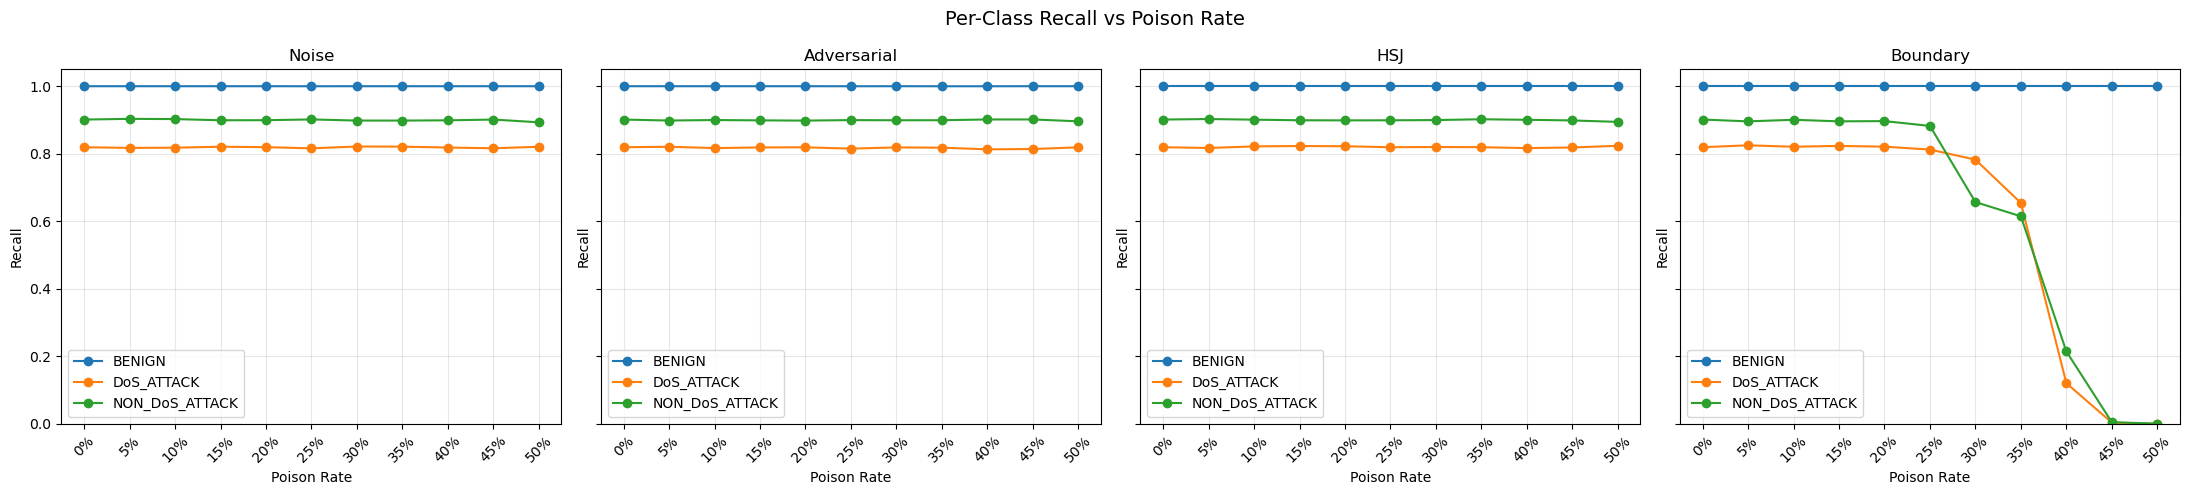


══ NOISE — PER-CLASS RECALL ══


,Group,Poison Rate,Recall (BENIGN),Recall (DoS_ATTACK),Recall (NON_DoS_ATTACK)
0,Control (0%),0%,1.0000,0.8194,0.9013
1,Experiment 1 (5%),5%,1.0000,0.8174,0.9034
2,Experiment 2 (10%),10%,1.0000,0.8180,0.9027
3,Experiment 3 (15%),15%,1.0000,0.8209,0.8992
4,Experiment 4 (20%),20%,1.0000,0.8196,0.8994
5,Experiment 5 (25%),25%,0.9999,0.8161,0.9017
6,Experiment 6 (30%),30%,1.0000,0.8215,0.8983
7,Experiment 7 (35%),35%,1.0000,0.8211,0.8983
8,Experiment 8 (40%),40%,1.0000,0.8185,0.8990
9,Experiment 9 (45%),45%,1.0000,0.8163,0.9013



══ ADVERSARIAL — PER-CLASS RECALL ══


,Group,Poison Rate,Recall (BENIGN),Recall (DoS_ATTACK),Recall (NON_DoS_ATTACK)
0,Control (0%),0%,1.0000,0.8194,0.9013
1,Experiment 1 (5%),5%,1.0000,0.8208,0.8984
2,Experiment 2 (10%),10%,1.0000,0.8168,0.8999
3,Experiment 3 (15%),15%,1.0000,0.8188,0.8989
4,Experiment 4 (20%),20%,1.0000,0.8192,0.8982
5,Experiment 5 (25%),25%,0.9999,0.8152,0.8997
6,Experiment 6 (30%),30%,1.0000,0.8189,0.8992
7,Experiment 7 (35%),35%,0.9999,0.8180,0.8993
8,Experiment 8 (40%),40%,0.9999,0.8132,0.9016
9,Experiment 9 (45%),45%,1.0000,0.8141,0.9016



══ HSJ — PER-CLASS RECALL ══


,Group,Poison Rate,Recall (BENIGN),Recall (DoS_ATTACK),Recall (NON_DoS_ATTACK)
0,Control (0%),0%,1.0,0.8194,0.9013
1,Experiment 1 (5%),5%,1.0,0.8172,0.9029
2,Experiment 2 (10%),10%,1.0,0.8218,0.9010
3,Experiment 3 (15%),15%,1.0,0.8230,0.8992
4,Experiment 4 (20%),20%,1.0,0.8223,0.8989
5,Experiment 5 (25%),25%,1.0,0.8194,0.8991
6,Experiment 6 (30%),30%,1.0,0.8201,0.8998
7,Experiment 7 (35%),35%,1.0,0.8195,0.9022
8,Experiment 8 (40%),40%,1.0,0.8168,0.9006
9,Experiment 9 (45%),45%,1.0,0.8186,0.8987



══ BOUNDARY — PER-CLASS RECALL ══


,Group,Poison Rate,Recall (BENIGN),Recall (DoS_ATTACK),Recall (NON_DoS_ATTACK)
0,Control (0%),0%,1.0,0.8194,0.9013
1,Experiment 1 (5%),5%,1.0,0.8251,0.8960
2,Experiment 2 (10%),10%,1.0,0.8208,0.9006
3,Experiment 3 (15%),15%,1.0,0.8233,0.8960
4,Experiment 4 (20%),20%,1.0,0.8210,0.8967
5,Experiment 5 (25%),25%,1.0,0.8125,0.8825
6,Experiment 6 (30%),30%,1.0,0.7826,0.6570
7,Experiment 7 (35%),35%,1.0,0.6545,0.6149
8,Experiment 8 (40%),40%,1.0,0.1209,0.2149
9,Experiment 9 (45%),45%,1.0,0.0042,0.0054


In [22]:
from sklearn.metrics import recall_score
import matplotlib.pyplot as plt

class_names = le.classes_
poison_labels = [f"{int(v*100)}%" for v in GROUPS.values()]

fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)
fig.suptitle("Per-Class Recall vs Poison Rate", fontsize=14)

for ax, source_name in zip(axes, ["Noise", "Adversarial", "HSJ", "Boundary"]):
    per_class_recall = {c: [] for c in class_names}
    for group_name in GROUPS:
        y_pred = group_preds[source_name][group_name]
        for i, cls in enumerate(class_names):
            mask = y_test == i
            if mask.sum() == 0:
                per_class_recall[cls].append(np.nan)
            else:
                per_class_recall[cls].append(np.mean(y_pred[mask] == i))

    for cls in class_names:
        ax.plot(poison_labels, per_class_recall[cls], marker="o", label=cls)
    ax.set_title(source_name)
    ax.set_xlabel("Poison Rate")
    ax.set_ylabel("Recall")
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

for source_name in ["Noise", "Adversarial", "HSJ", "Boundary"]:
    print(f"\n══ {source_name.upper()} — PER-CLASS RECALL ══")
    rows = []
    for group_name, poison_rate in GROUPS.items():
        y_pred = group_preds[source_name][group_name]
        row = {"Group": group_name, "Poison Rate": f"{int(poison_rate*100)}%"}
        for i, cls in enumerate(class_names):
            mask = y_test == i
            row[f"Recall ({cls})"] = round(np.mean(y_pred[mask] == i), 4) if mask.sum() > 0 else np.nan
        rows.append(row)
    display(pd.DataFrame(rows))